# Ejemplo de entrenamiento para ClothML
Este notebook corresponde al experimento RNN, puede cambiarse el tipo de modelo a MLP.

----
## 1. Carga de datos, elección de features

In [3]:
import pandas as pd
import numpy as np
import torch
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

output_path = 'holasoyeva' # Nombre para archivos generados (JSON, ONNX)
csv_path = 'data/clothDataset_92_' # Nombre del dataset de la simulación
df = pd.read_csv(csv_path + '.csv')

# Características de la tela y selección de features
num_vertices = 25

num_features = 4 # x, y, z, sdf 

selected_columns = []
for i in range(num_vertices):
    selected_columns.extend([f'x{i}', f'y{i}', f'z{i}', f'sdf{i}'])

df_filtered = df[selected_columns]
data_flat = df_filtered.values
num_frames = data_flat.shape[0]

# Tensor! :)
data_3d = data_flat.reshape((num_frames, num_vertices, num_features))
data_tensor = torch.tensor(data_3d, dtype=torch.float32)

print(f"Frames totales: {num_frames}")
print(f"Tensor shape: {data_tensor.shape}  # [Frames, Vertices, Features]")

Frames totales: 12499
Tensor shape: torch.Size([12499, 25, 4])  # [Frames, Vertices, Features]



## 2. Datasets 
Loaders, normalización

In [4]:
import ClothDataset
from Normalizacion import Norm

SEQ_LEN      = 16   # frames de historia que ve la RNN
ROLLOUT_STEPS = 24  # W del paper: cuántos pasos futuros se predicen durante training
BATCH_SIZE   = 32

dataset = ClothDataset.ClothUnrolledDataset(data_tensor, seq_len=SEQ_LEN, rollout_steps=ROLLOUT_STEPS)

# Split cronológico (más honesto para física temporal)
train_size = int(0.8 * len(dataset))
train_dataset = torch.utils.data.Subset(dataset, range(train_size))
test_dataset  = torch.utils.data.Subset(dataset, range(train_size, len(dataset)))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Verificar shapes
seq_b, fut_b = next(iter(train_loader))
print(f"sequence shape:      {seq_b.shape}   # [B, seq_len, V, F]")
print(f"future_frames shape: {fut_b.shape}  # [B, rollout, V, F]")

# Normalización
norm_data = Norm(train_loader, num_features)
norm_data.save_stats_JSON(output_path) # Estadísticas de normalización exportadas para usar después en la simulación

sequence shape:      torch.Size([32, 16, 25, 4])   # [B, seq_len, V, F]
future_frames shape: torch.Size([32, 24, 25, 4])  # [B, rollout, V, F]
holasoyeva.json



## 3. Modelo

In [5]:
import Modelos

HIDDEN_SIZE = 128
model = Modelos.FlatRNNClothUnity(num_vertices=num_vertices,
                          num_features=num_features,
                          hidden_size=HIDDEN_SIZE,
                          num_outputs=3)
criterion   = nn.L1Loss()
optimizer   = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler   = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros totales: {total_params:,}")

Parámetros totales: 39,115



## 4. Función de Unrolling para el entrenamiento

In [6]:

def run_rollout(batch_seq, batch_future, add_noise=False):
    """
    Aplica la técnica de unfolding/unrolling sobre un batch 
    batch_seq:    [B, seq_len, V, F]   — historia inicial
    batch_future: [B, rollout, V, F]   — frames reales futuros
    
    Retorna el loss acumulado (posición + velocidad) sobre los W pasos.
    """
    B, W, V, F = batch_future.shape
    
    # Ventana deslizante de posiciones absolutas  [B, seq_len, V, F]
    # Hacemos clone para no modificar el tensor original (lo necesita pytorch para el backward)
    window = batch_seq.clone() 

    # Ruido inicial en los 2 últimos frames de la historia 
    if add_noise:
        noise = torch.randn_like(window[:, -2:, :, :]) * NOISE_SIGMA
        window[:, -2:, :, :] = window[:, -2:, :, :] + noise

    # Inicialización del loss
    total_loss = torch.tensor(0.0, device=batch_seq.device)

    prev_pred_pos = window[:, -1, :, 0:3]   # posición del último frame conocido COMO HACEMOS FEEDBACK ES IGUAL A prev_pred_pos
    for k in range(W):
        # Forward: Inferencia
        window_norm = norm_data.norm_input(window)   # Ventana de input normalizada [B, seq_len, V, F]
        pred_delta_norm = model(window_norm)         # Desplazamiento inferido normalizado en t [B, V, 3]

        last_pos = window[:, -1, :, 0:3]      
        pred_delta_real = norm_data.denorm_delta(pred_delta_norm)   # Desplazamiento desnormalizado
        pred_pos = last_pos + pred_delta_real      # Nueva posición a partir de la última posición predicha y el desplazamiento inferido

        # Posiciones reales para la comparación (targets)
        real_pos = batch_future[:, k, :, 0:3]     # Posición real en t
        real_prev_pos = (
            batch_future[:, k-1, :, 0:3] if k > 0 # A partir del primer paso los últimos frames de la ventana han sido predichos, por lo que los frames reales están en batch_future
            else batch_seq[:, -1, :, 0:3]         # En el primer paso, el frame es el último en la ventana de input
        )

        # Loss de posición: diferencia entre el desplazamiento predicho y el desplazamiento necesario para llegar a la posición correcta real
        real_delta      = real_pos - last_pos # Es decir, el desplazamiento necesario para corregirse en ese frame
        real_delta_norm = norm_data.norm_delta(real_delta)
        loss_pos = criterion(pred_delta_norm, real_delta_norm)  

        # Loss velocidad: diferencia entre desplazamiento real e inferido entre t y t-1
        pred_vel = pred_pos - prev_pred_pos     
        real_vel = real_pos - real_prev_pos       
        # Norm 
        loss_vel = criterion(
            pred_vel / norm_data.target_std.clamp(min=1e-8),
            real_vel / norm_data.target_std.clamp(min=1e-8)
        )

        # El loss total está compuesto por cuánto desplazamiento ha conseguido realizar para corregirse (loss_pos) y cuánta cantidad de movimiento difiere del real (loss_vel)
        total_loss = total_loss + loss_pos + VEL_WEIGHT * loss_vel

        # pred_pos → nuevo último frame de la ventana
        # Construimos el nuevo frame predicho con x,y,z + sdf del real
        # (El sdf no lo predecimos, usamos el real como aprox)
        new_frame = window[:, -1, :, :].clone()   # copia del último frame
        new_frame[:, :, 0:3] = pred_pos.detach() if not model.training else pred_pos

        # Desplazamos la ventana: quitamos el frame más antiguo, añadimos la predicción
        window = torch.cat([window[:, 1:, :, :], new_frame.unsqueeze(1)], dim=1)

        prev_pred_pos = pred_pos

    return total_loss / W

## 5. Entrenamiento

In [7]:
# Parámetros para el entrenamiento 
EPOCHS      = 1
NOISE_SIGMA = 0.03   # Ruido en los 2 frames iniciales
VEL_WEIGHT  = 1.0    # Peso de loss_vel en la suma de losses del rollout
history = {'train': [], 'test': [], 'vertex_error': []}

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for batch_seq, batch_future in train_loader:
        batch_seq    = batch_seq.float()
        batch_future = batch_future.float()

        loss = run_rollout(batch_seq, batch_future, add_noise=True)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    scheduler.step()
    avg_train = train_loss / len(train_loader)

    # ── TEST ─────────────────────────────────────────────────────
    model.eval()
    test_loss  = 0.0
    total_err  = 0.0
    total_verts = 0

    all_pred_pos   = []
    all_target_pos = []

    with torch.no_grad():
        for batch_seq, batch_future in test_loader:
            batch_seq    = batch_seq.float()
            batch_future = batch_future.float()

            loss = run_rollout(batch_seq, batch_future, add_noise=False)
            test_loss += loss.item()

            # Para métricas, evaluamos solo el primer frame predicho
            window_norm  = norm_data.norm_input(batch_seq)
            pred_dn      = model(window_norm)
            last_pos     = batch_seq[:, -1, :, 0:3]
            pred_pos     = last_pos + norm_data.denorm_delta(pred_dn)
            target_pos   = batch_future[:, 0, :, 0:3]

            all_pred_pos.append(pred_pos.cpu().numpy())
            all_target_pos.append(target_pos.cpu().numpy())

            distances = torch.norm(pred_pos - target_pos, dim=-1)
            total_err   += distances.sum().item()
            total_verts += distances.numel()

    avg_test     = test_loss  / len(test_loader)
    avg_vert_err = total_err  / total_verts


    history['train'].append(avg_train)
    history['test'].append(avg_test)
    history['vertex_error'].append(avg_vert_err)

    preds_pos_np   = np.concatenate(all_pred_pos,   axis=0)
    targets_pos_np = np.concatenate(all_target_pos, axis=0)

    if epoch % 30 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train: {avg_train:.6f} | "
              f"Test: {avg_test:.6f} | VertErr: {avg_vert_err:.6f}")

    # ONNX intermedios
    if epoch == 2:
        dummy_input = torch.randn(1, SEQ_LEN, num_vertices, num_features)

        onnx_program = torch.onnx.export(
            model,
            dummy_input,
            output_path + "mid.onnx",
            export_params=True,
            opset_version=15,
            input_names=['input'],
            output_names=['output'],
        )

print("\nEntrenamiento completado.")

Epoch 001 | Train: 24.846185 | Test: 5.604196 | VertErr: 0.004994

Entrenamiento completado.


## 6. Visualización de resultados
Visualizamos los losses, error de vértice a través del entrenamiento, así como la propogación de error en el rollout en un paso y sobre varios en 3D.

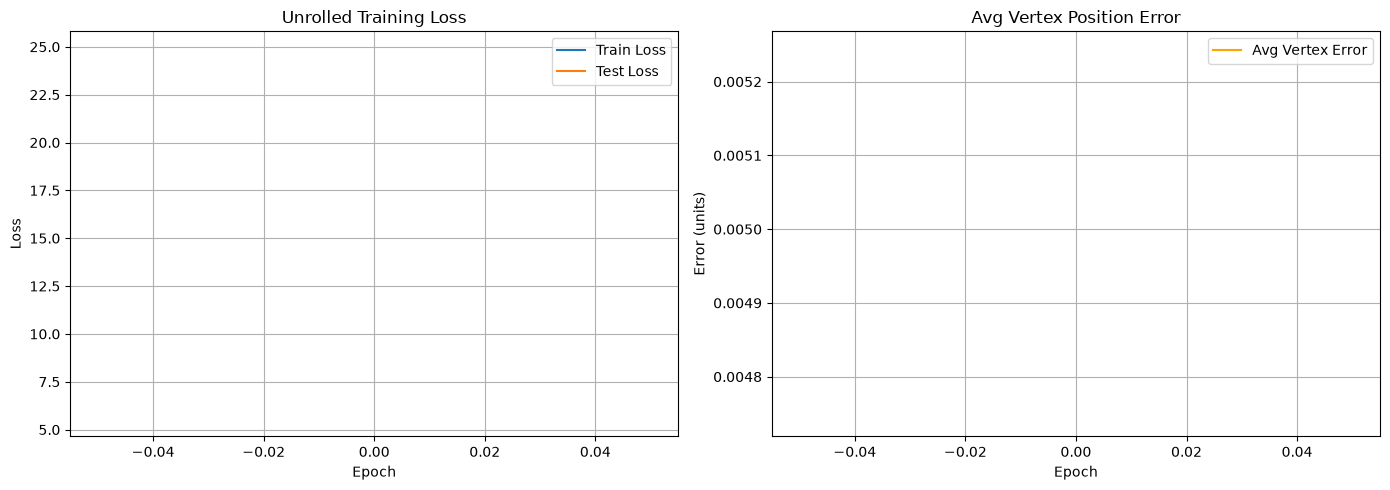

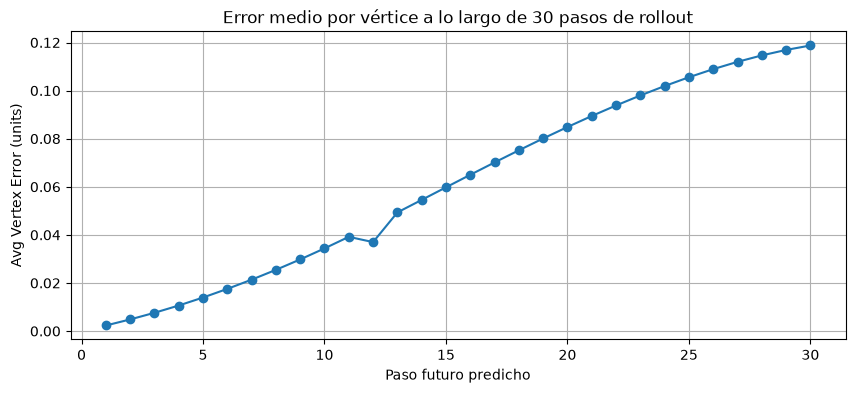

Unrolling correcto con el aumento progresivo de la curva. Si explota aumentar los pasos de rollout o noise.


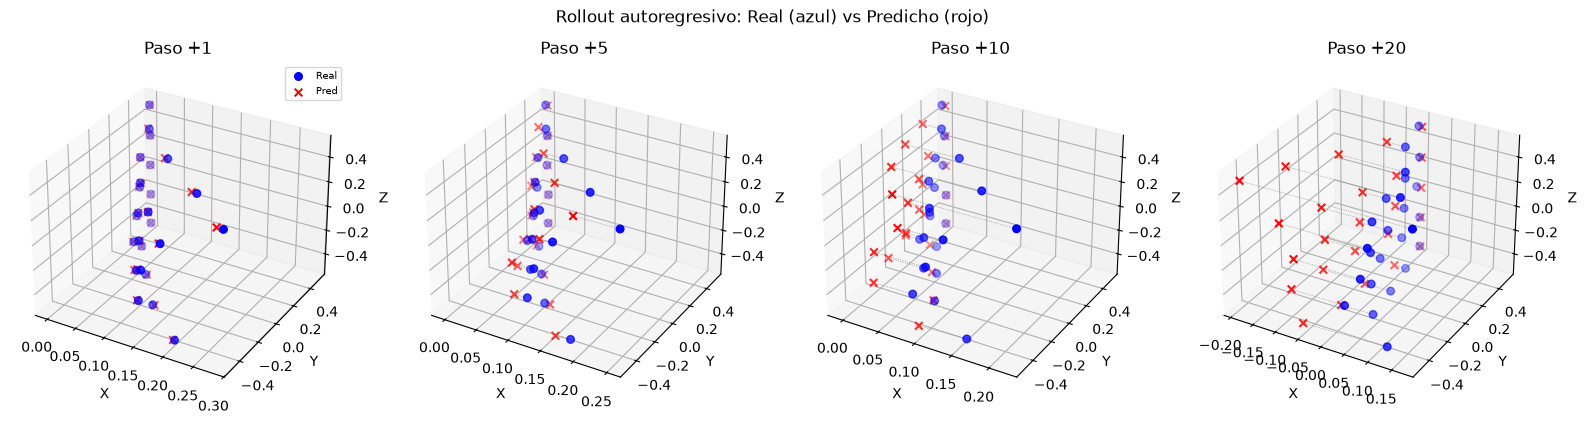

In [8]:
import matplotlib.pyplot as plt
import Visualizacion

Visualizacion.plot_loss_curves(history)
model.eval()
rollout_preds, rollout_reals = Visualizacion.get_rollout_params(model, test_loader, train_size, SEQ_LEN, data_tensor, norm_data)
Visualizacion.plot_rollout_error(rollout_preds, rollout_reals, 30)
Visualizacion.plot_3d_rollout(rollout_preds, rollout_reals, 25)


## 7. Export a ONNX
*(Compatible con Unity — misma forma de entrada que rnn01)*

In [9]:
import Export
Export.ONNX_export(model, (1, SEQ_LEN, 25, 4), output_path)

torch.Size([1, 16, 25, 4])
ONNX output shape: (1, 25, 3)
ONNX export llevado a cabo con éxito.
